# 🔬 Partie 4 — Analyses avancées de données

> Ce notebook couvre :
> - La sélection de features (Filtres, Wrappers, ML intrinsèque)
> - La réduction de dimensions (PCA, LDA, t-SNE)
> - Les métriques avancées (R², ROC, AUC)

## 📦 1. Imports

In [1]:
# ──────────────────────────────────────────────────
# AFFICHAGE DYNAMIQUE
# ──────────────────────────────────────────────────
from IPython.display import Markdown, display    # Affichage markdown dynamique

# ──────────────────────────────────────────────────
# MANIPULATION DE DONNÉES
# ──────────────────────────────────────────────────
import numpy as np                                # Calculs numériques
import pandas as pd                               # DataFrames

# ──────────────────────────────────────────────────
# VISUALISATION
# ──────────────────────────────────────────────────
import matplotlib.pyplot as plt                   # Graphiques
import matplotlib.patches as mpatches            # Légendes personnalisées

# ──────────────────────────────────────────────────
# DATASETS DE DÉMONSTRATION
# ──────────────────────────────────────────────────
from sklearn.datasets import (
    load_iris,           # Dataset Iris (classification 3 classes)
    load_diabetes,       # Dataset Diabète (régression)
    make_classification, # Génération de données de classification
    make_regression      # Génération de données de régression
)

# ──────────────────────────────────────────────────
# FEATURE SELECTION — FILTRES
# ──────────────────────────────────────────────────
from sklearn.feature_selection import (
    SelectKBest,          # Sélection des K meilleures features
    f_classif,            # Score ANOVA F (numérique → catégorie)
    f_regression,         # Score F de corrélation (numérique → numérique)
    chi2,                 # Test Chi² (catégorie → catégorie)
    mutual_info_classif   # Information mutuelle (agnostique)
)

# ──────────────────────────────────────────────────
# FEATURE SELECTION — WRAPPER
# ──────────────────────────────────────────────────
from sklearn.feature_selection import RFE        # Recursive Feature Elimination
from sklearn.feature_selection import RFECV      # RFE avec validation croisée

# ──────────────────────────────────────────────────
# MODÈLES POUR FEATURE SELECTION
# ──────────────────────────────────────────────────
from sklearn.svm import SVR, SVC                 # Support Vector Machines
from sklearn.ensemble import RandomForestClassifier  # Random Forest
from sklearn.linear_model import LogisticRegression  # Régression logistique

# ──────────────────────────────────────────────────
# RÉDUCTION DE DIMENSIONS
# ──────────────────────────────────────────────────
from sklearn.decomposition import PCA            # Principal Component Analysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA  # LDA
from sklearn.manifold import TSNE                # t-SNE

# ──────────────────────────────────────────────────
# PRÉPROCESSING & ÉVALUATION
# ──────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler         # Standardisation
from sklearn.model_selection import train_test_split      # Découpage train/test
from sklearn.pipeline import Pipeline                     # Pipeline sklearn

# ──────────────────────────────────────────────────
# MÉTRIQUES AVANCÉES
# ──────────────────────────────────────────────────
from sklearn.metrics import (
    r2_score,              # Coefficient de détermination R²
    roc_curve,             # Courbe ROC (FP rate vs TP rate)
    auc,                   # Aire sous la courbe (AUC)
    roc_auc_score,         # AUC directement depuis les probabilités
    mean_squared_error,    # Erreur quadratique moyenne
    accuracy_score         # Accuracy pour la classification
)

# Graine pour la reproductibilité
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Imports chargés avec succès")

✅ Imports chargés avec succès


---
## 🔍 2. Analyse de composantes — Feature Selection

### 2.1 Pourquoi sélectionner des features ?

Quand un dataset a beaucoup de colonnes (features), toutes ne sont pas utiles.  
Certaines peuvent même **nuire** aux performances du modèle.

**Deux objectifs de la sélection de features :**

| Objectif | Explication |
|----------|-------------|
| **Réduire le coût d'entraînement** | Moins de features = calculs plus rapides, moins de mémoire |
| **Augmenter la performance** | Supprimer le bruit améliore souvent la précision du modèle |

**Le problème de la malédiction de la dimensionnalité :**

Plus il y a de features, plus l'espace des données devient **vide**.  
Un dataset de 100 exemples avec 50 features : le modèle a trop peu d'exemples par rapport aux dimensions.

```
1D (1 feature)   : ────────────────────────────  (données denses)
2D (2 features)  : □□□□□□□□□□□□□□□□□□□□□□□□□□□  (moins denses)
3D (3 features)  : □□□□□□□□  (encore moins...)
50D (50 features): □  (les données sont isolées dans un espace immense !)
```

> ⚠️ **Attention !** La sélection de features **choisit** des colonnes existantes.  
> La réduction de dimensions **crée** de nouvelles colonnes en combinant les anciennes.  
> Ce sont deux approches différentes !

### 2.2 Les 3 catégories de méthodes

Il existe **trois grandes familles** de méthodes de sélection de features :

```
┌─────────────────────────────────────────────────────────────────────┐
│                    FEATURE SELECTION                                │
├───────────────┬──────────────────────┬──────────────────────────────┤
│   FILTRES     │      WRAPPER         │      ML INTRINSÈQUE          │
│               │                      │                              │
│ Analyse       │ Plusieurs modèles    │ Fonction native du modèle    │
│ statistique   │ avec différentes     │                              │
│ pure          │ combinaisons de      │                              │
│               │ features             │                              │
│ Ex:           │                      │ Ex:                          │
│ Pearson,      │ Ex:                  │ RandomForest.feature_        │
│ Chi², ANOVA   │ RFE, Forward,        │ importances_                 │
│               │ Backward             │ Lasso (L1 pénalise 0)        │
│ ✅ Rapide     │ ✅ Précis            │ ✅ Intégré au modèle         │
│ ❌ Pas de     │ ❌ Très lent         │ ❌ Dépend du modèle choisi   │
│    contexte   │    (bruteforce)      │                              │
└───────────────┴──────────────────────┴──────────────────────────────┘
```

**Deux approches selon l'accès à la target :**

| Approche | Utilise la target ? | Cas d'usage |
|----------|--------------------|--------------|
| **Supervisée** | ✅ Oui | On connaît la colonne à prédire |
| **Non supervisée** | ❌ Non | Pas de target (clustering, exploration) |

### 2.3 Approches supervisée vs non supervisée

La distinction entre supervisé et non supervisé s'applique aussi à la sélection de features.

**Supervisée** (avec la target `y`) :
- On mesure la **relation entre chaque feature et la target**
- Exemples : SelectKBest (f_classif), RFE, feature_importances de RandomForest
- On élimine les features qui n'expliquent pas la target

**Non supervisée** (sans la target) :
- On mesure la **variance** ou la **redondance** entre les features elles-mêmes
- Exemples : supprimer les features à variance quasi-nulle, supprimer les features très corrélées entre elles
- Utile en phase d'exploration ou quand la target n'est pas encore définie

```python
# Exemple non supervisé : supprimer features à variance nulle
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold(threshold=0.01)  # Variance < 1% → supprimée
X_reduit = selector.fit_transform(X)
```

### 2.4 Algorithmes de Filtre — tableau de décision

Les **filtres** calculent un **score statistique** entre chaque feature et la target.  
Le choix du test dépend du **type de données** (numérique ou catégorielle).

| Entrée (X) | Sortie (y) | Relation | Méthode recommandée |
|-----------|-----------|---------|---------------------|
| Numérique | Numérique | Linéaire | **Corrélation de Pearson** |
| Numérique | Numérique | Non-linéaire | **Corrélation de Spearman** |
| Numérique | Catégorie | Linéaire | **ANOVA (f_classif)** |
| Numérique | Catégorie | Non-linéaire | **Corrélation de Kendall** |
| Catégorie | Catégorie | — | **Test Chi²** |
| Tout type | Tout type | Quelconque | **Mutual Information Score** ⭐ |

> ⭐ **Mutual Information** : méthode la plus **agnostique** — fonctionne dans tous les cas.  
> C'est la méthode conseillée par Florian AUBRY quand on ne sait pas quelle relation existe.

**Comment interpréter les scores ?**  
- Score **élevé** → la feature est fortement reliée à la target → à **conserver**
- Score **proche de 0** → la feature apporte peu d'information → à **supprimer**

=== Dataset Iris ===
Features : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes  : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
Shape    : (150, 4)

=== Scores des features ===
          Feature  ANOVA (f_classif)  Mutual Info
petal length (cm)            1180.16       0.9926
 petal width (cm)             960.01       0.9856
sepal length (cm)             119.26       0.5114
 sepal width (cm)              49.16       0.2994


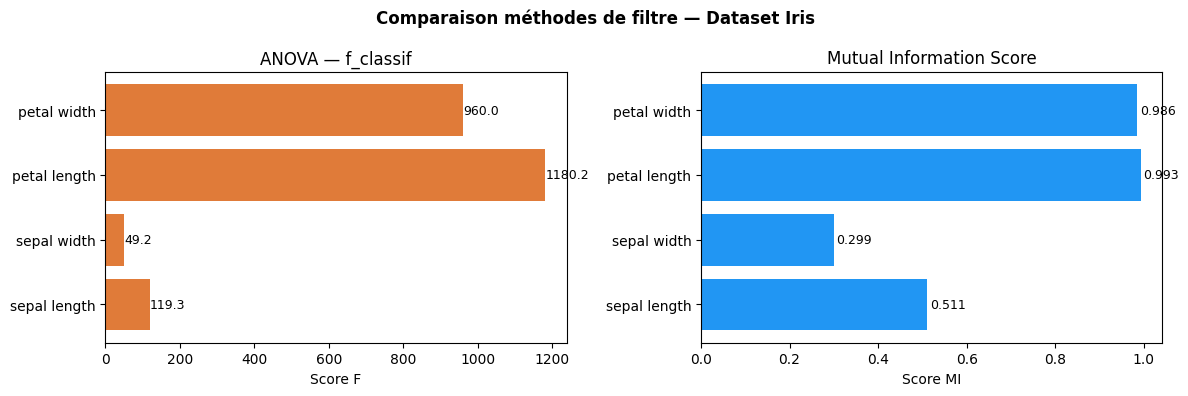

In [2]:
# ── Démonstration : comparaison de 3 méthodes de filtre ───────────────────

# Dataset Iris : 4 features numériques, target = espèce (catégorie)
iris       = load_iris()
X_iris     = pd.DataFrame(iris.data,   columns=iris.feature_names)
y_iris     = pd.Series(iris.target,    name='espece')

print("=== Dataset Iris ===")
print(f"Features : {list(X_iris.columns)}")
print(f"Classes  : {list(iris.target_names)}")
print(f"Shape    : {X_iris.shape}")

# ── Méthode 1 : ANOVA f_classif ───────────────────────────────────────────
selector_anova = SelectKBest(score_func=f_classif, k='all')
selector_anova.fit(X_iris, y_iris)
scores_anova   = selector_anova.scores_

# ── Méthode 2 : Mutual Information ────────────────────────────────────────
selector_mi  = SelectKBest(score_func=mutual_info_classif, k='all')
selector_mi.fit(X_iris, y_iris)
scores_mi    = selector_mi.scores_

# ── Tableau de comparaison ────────────────────────────────────────────────
df_scores = pd.DataFrame({
    'Feature'          : iris.feature_names,
    'ANOVA (f_classif)': np.round(scores_anova, 2),
    'Mutual Info'      : np.round(scores_mi,    4),
})
df_scores = df_scores.sort_values('ANOVA (f_classif)', ascending=False)

print("\n=== Scores des features ===")
print(df_scores.to_string(index=False))

# Visualisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Comparaison méthodes de filtre — Dataset Iris", fontsize=12, fontweight='bold')
noms = [n.replace(' (cm)', '') for n in iris.feature_names]

ax1.barh(noms, scores_anova, color='#e07b39')
ax1.set_title("ANOVA — f_classif")
ax1.set_xlabel("Score F")
for i, v in enumerate(scores_anova):
    ax1.text(v + 1, i, f'{v:.1f}', va='center', fontsize=9)

ax2.barh(noms, scores_mi, color='#2196f3')
ax2.set_title("Mutual Information Score")
ax2.set_xlabel("Score MI")
for i, v in enumerate(scores_mi):
    ax2.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

📌 Ce que j'observe

Les deux méthodes s'accordent sur le **classement** des features : `petal length` et `petal width` sont les plus importantes.  
ANOVA donne des scores en valeurs absolues (scores F), Mutual Info donne des scores entre 0 et 1.  
Le Mutual Information est plus général — il détecte aussi les relations **non-linéaires** que l'ANOVA manquerait.

### 2.5 SelectKBest — code & démonstration

`SelectKBest` est l'outil sklearn qui applique un filtre et **conserve les K meilleures features**.  

**Paramètres clés :**
- `score_func` : le test statistique à utiliser (`f_classif`, `chi2`, `mutual_info_classif`...)
- `k` : nombre de features à conserver (`'all'` pour voir tous les scores, puis choisir)

**Attributs après `.fit()` :**
- `.scores_` : score de chaque feature
- `.pvalues_` : p-value associée (probabilité que le score soit dû au hasard)
- `.get_support()` : masque booléen des features sélectionnées

=== Scores SelectKBest (ANOVA) ===
   Feature   Score  P-value
 Feature_8 53.5930   0.0000
 Feature_7 41.4823   0.0000
 Feature_9 36.9428   0.0000
 Feature_1 36.2804   0.0000
 Feature_4 12.7800   0.0004
Feature_10  3.9108   0.0487
 Feature_6  0.3299   0.5661
 Feature_5  0.2498   0.6175
 Feature_2  0.1717   0.6788
 Feature_3  0.1018   0.7499


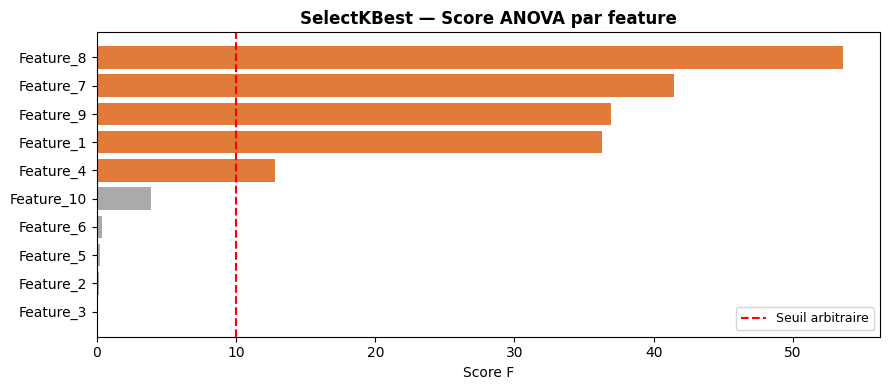

**Top 5 features sélectionnées :** `['Feature_1', 'Feature_4', 'Feature_7', 'Feature_8', 'Feature_9']`

In [5]:
# ── SelectKBest : exemple du cours (style BankChurners) ───────────────────
# Génération d'un dataset synthétique avec features redondantes

X_synth, y_synth = make_classification(
    n_samples    = 500,
    n_features   = 10,       # 10 features au total
    n_informative = 4,       # Seulement 4 vraiment utiles
    n_redundant   = 3,       # 3 redondantes (combinaisons de features utiles)
    random_state  = RANDOM_STATE
)

noms_features = [f'Feature_{i+1}' for i in range(10)]
X_df = pd.DataFrame(X_synth, columns=noms_features)

X_train, X_test, y_train, y_test = train_test_split(
    X_df, y_synth, test_size=0.2, random_state=RANDOM_STATE
)

# SelectKBest avec ANOVA (numérique → catégorie)
kbest = SelectKBest(score_func=f_classif, k='all')
kbest.fit(X_train, y_train)

# Résultats triés
kbest_scores = pd.DataFrame({
    'Feature' : X_train.columns,
    'Score'   : kbest.scores_,
    'P-value' : kbest.pvalues_
})
kbest_scores.sort_values(by='Score', ascending=False, inplace=True)
kbest_scores.reset_index(drop=True, inplace=True)

print("=== Scores SelectKBest (ANOVA) ===")
print(kbest_scores.round(4).to_string(index=False))

# Visualisation (style cours Florian AUBRY)
fig, ax = plt.subplots(figsize=(9, 4))
couleurs = ['#e07b39' if s > 10 else '#aaaaaa' for s in kbest_scores['Score']]
ax.barh(kbest_scores['Feature'], kbest_scores['Score'], color=couleurs)
ax.set_title("SelectKBest — Score ANOVA par feature", fontsize=12, fontweight='bold')
ax.set_xlabel("Score F")
ax.axvline(10, color='red', linestyle='--', linewidth=1.5, label='Seuil arbitraire')
ax.legend(fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Sélection des K=5 meilleures features
kbest_k5 = SelectKBest(score_func=f_classif, k=5)
kbest_k5.fit(X_train, y_train)
features_selectionnees = X_train.columns[kbest_k5.get_support()]
display(Markdown(f"**Top 5 features sélectionnées :** `{list(features_selectionnees)}`"))

📌 Ce que j'observe

Les features avec un score F élevé sont celles qui varient significativement selon la classe.  
Les features avec score proche de 0 et p-value élevée sont du bruit pur — inutiles pour le modèle.  
En pratique, on lance d'abord avec `k='all'` pour voir les scores, puis on choisit K.

### 2.6 Algorithmes Wrapper

Les **Wrappers** utilisent un modèle ML pour évaluer les combinaisons de features.  
Ils sont plus précis que les filtres mais beaucoup plus **coûteux en temps de calcul**.

**Trois stratégies :**

```
┌─────────────────────────────────────────────────────────────────┐
│  FORWARD SELECTION (Ajout progressif)                           │
│                                                                 │
│  Départ : 0 feature                                             │
│  Étape 1 : Tester chaque feature seule → garder la meilleure   │
│  Étape 2 : Tester chaque feature + celle de l'étape 1          │
│  → Recommencer jusqu'à atteindre K features                    │
└─────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────┐
│  BACKWARD ELIMINATION (Suppression progressive)                 │
│                                                                 │
│  Départ : toutes les features                                   │
│  Étape 1 : Supprimer la feature la moins utile                  │
│  → Recommencer jusqu'à atteindre K features                    │
└─────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────┐
│  EXHAUSTIVE (Bruteforce)                                        │
│                                                                 │
│  Tester TOUTES les combinaisons possibles                       │
│  → Optimal mais exponentiel : 2ⁿ combinaisons pour n features  │
│  → Inutilisable au-delà de ~15 features                        │
└─────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────┐
│  RFE — Recursive Feature Elimination ⭐                         │
│                                                                 │
│  1. Entraîner le modèle sur toutes les features                 │
│  2. Mesurer l'importance de chaque feature (poids du modèle)    │
│  3. Supprimer la moins importante                               │
│  4. Répéter jusqu'à atteindre n_features_to_select             │
└─────────────────────────────────────────────────────────────────┘
```

> ⭐ **RFE est le wrapper le plus utilisé en pratique** — bon compromis entre précision et vitesse.

### 2.7 RFE — Recursive Feature Elimination

=== RFE avec SVR linéaire ===

Masque (True = sélectionnée) :
  [ True  True False False False False  True  True False  True]

Classement (1 = meilleure, N = moins bonne) :
  [1 1 4 6 5 3 1 1 2 1]

=== Tableau des résultats ===
   Feature  Sélectionnée  Classement
 Feature_1          True           1
 Feature_2          True           1
 Feature_7          True           1
 Feature_8          True           1
Feature_10          True           1
 Feature_9         False           2
 Feature_6         False           3
 Feature_3         False           4
 Feature_5         False           5
 Feature_4         False           6



**Features sélectionnées par RFE :** `['Feature_1', 'Feature_2', 'Feature_7', 'Feature_8', 'Feature_10']`

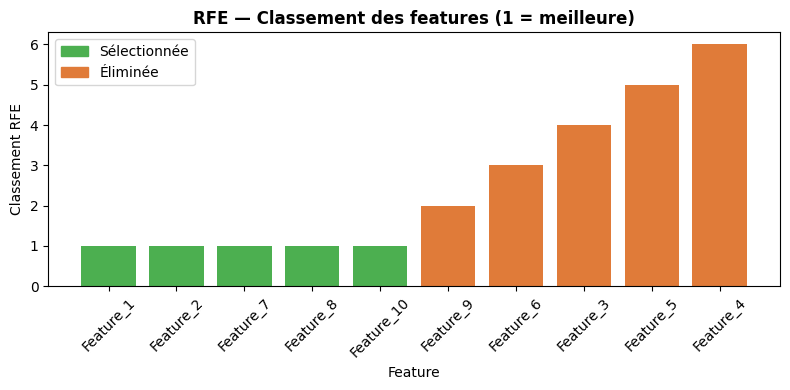

In [6]:
# ── RFE avec SVM (exemple du cours) ───────────────────────────────────────

# Le modèle de base pour la sélection : SVR linéaire
# (SVR attribue des poids aux features → RFE s'en sert pour les classer)
modele_base = SVR(kernel='linear')

# RFE : garder les 5 meilleures features
selector_rfe = RFE(
    estimator         = modele_base,
    n_features_to_select = 5,  # Nombre de features à conserver
    step              = 1      # Supprimer 1 feature par itération
)
selector_rfe.fit(X_train, y_train)

# Résultats
print("=== RFE avec SVR linéaire ===")
print(f"\nMasque (True = sélectionnée) :")
print(f"  {selector_rfe.support_}")
print(f"\nClassement (1 = meilleure, N = moins bonne) :")
print(f"  {selector_rfe.ranking_}")

# Tableau détaillé
df_rfe = pd.DataFrame({
    'Feature'      : X_train.columns,
    'Sélectionnée' : selector_rfe.support_,
    'Classement'   : selector_rfe.ranking_
}).sort_values('Classement')

print("\n=== Tableau des résultats ===")
print(df_rfe.to_string(index=False))

features_rfe = X_train.columns[selector_rfe.support_]
display(Markdown(f"\n**Features sélectionnées par RFE :** `{list(features_rfe)}`"))

# Visualisation du classement
fig, ax = plt.subplots(figsize=(8, 4))
couleurs_rfe = ['#4caf50' if s else '#e07b39' for s in df_rfe['Sélectionnée']]
ax.bar(df_rfe['Feature'], df_rfe['Classement'], color=couleurs_rfe)
ax.set_title("RFE — Classement des features (1 = meilleure)", fontsize=12, fontweight='bold')
ax.set_ylabel("Classement RFE")
ax.set_xlabel("Feature")
ax.tick_params(axis='x', rotation=45)
vert  = mpatches.Patch(color='#4caf50', label='Sélectionnée')
rouge = mpatches.Patch(color='#e07b39', label='Éliminée')
ax.legend(handles=[vert, rouge])
plt.tight_layout()
plt.show()

📌 Ce que j'observe

Les features avec `classement = 1` sont les plus importantes selon le SVR.  
Le classement n'est pas identique à celui de SelectKBest — **les méthodes peuvent diverger** sur les cas limites.  
C'est normal : filtres et wrappers mesurent des choses différentes (relation statistique vs utilité pour le modèle).

### 2.8 ML intrinsèque — Feature Importances

Certains modèles ML produisent **nativement** une mesure d'importance des features.  
Pas besoin d'outil externe — c'est intégré au modèle lui-même.

**Modèles avec feature importance native :**

| Modèle | Attribut | Comment c'est calculé |
|--------|----------|----------------------|
| **RandomForest** | `.feature_importances_` | Réduction d'impureté (Gini) moyenne par feature |
| **GradientBoosting / XGBoost** | `.feature_importances_` | Gain moyen quand la feature est utilisée |
| **Lasso (L1)** | `.coef_` | Les features inutiles ont un coefficient = 0 |
| **SVM linéaire** | `.coef_` | Poids dans la frontière de décision |

=== RandomForest — Feature Importances ===
   Feature  Importance
 Feature_8      0.2380
 Feature_2      0.1335
 Feature_5      0.1174
 Feature_1      0.1106
 Feature_7      0.0962
 Feature_9      0.0940
 Feature_4      0.0770
 Feature_6      0.0529
 Feature_3      0.0405
Feature_10      0.0400


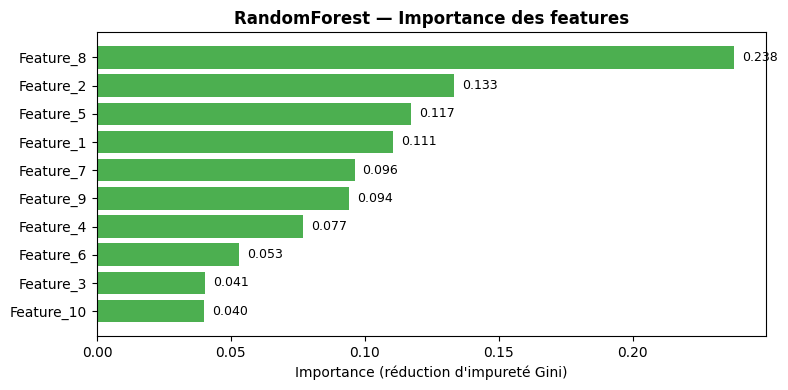

In [7]:
# ── RandomForest feature_importances_ ─────────────────────────────────────

rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

# Récupération des importances
importances = pd.DataFrame({
    'Feature'   : X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("=== RandomForest — Feature Importances ===")
print(importances.round(4).to_string(index=False))

# Visualisation
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(importances['Feature'], importances['Importance'], color='#4caf50')
ax.set_title("RandomForest — Importance des features", fontsize=12, fontweight='bold')
ax.set_xlabel("Importance (réduction d'impureté Gini)")
ax.invert_yaxis()
for i, v in enumerate(importances['Importance']):
    ax.text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### 2.9 Comment choisir sa méthode ?

Comme le dit Florian AUBRY : **il faut tester**.  
La meilleure méthode dépend de la nature des données, de leur répartition, du modèle final.

**Guide pratique :**

```
Beaucoup de features ?  →  Commencer par un FILTRE (rapide)
         ↓
Résultat insatisfaisant ?  →  Passer à RFE
         ↓
Encore incertain ?  →  Utiliser feature_importances_ du modèle final
         ↓
Combiner les features importantes + réduction de dimension
```

**Règle d'or :**
- **Filtres** en premier passage (rapide, donne une idée)
- **RFE ou feature_importances_** pour affiner
- **Mutual Information** quand on ne connaît pas le type de relation
- Toujours **valider** sur le test set après sélection

---
## 📉 3. Réduction de dimensions

### 3.1 Feature Selection vs Réduction de dimension — la différence clé

C'est une **confusion fréquente** — clarification essentielle :

```
FEATURE SELECTION                    RÉDUCTION DE DIMENSION
──────────────────                   ──────────────────────
Données originales :                 Données originales :
[Age, Salaire, NbEnfants, Ville]     [Age, Salaire, NbEnfants, Ville]
         ↓                                    ↓
ON CHOISIT des colonnes              ON CRÉE de nouvelles colonnes
         ↓                                    ↓
[Age, Salaire]                       [Composante1, Composante2]
                                     (combinaison des 4 originales)

✅ Les colonnes restent lisibles     ❌ Les nouvelles colonnes sont
✅ Interprétable                        abstraites / moins lisibles
❌ Ne capture pas les interactions   ✅ Capture les corrélations
   entre features                    ✅ Très efficace pour visualiser
```

> 💡 **Ils ne s'excluent pas !**  
> On peut sélectionner les meilleures features **ET** ajouter des composantes PCA.  
> Les deux approches se combinent pour enrichir la représentation des données.

### 3.2 PCA — Principal Component Analysis

La **PCA** transforme les features originales en **composantes principales** non corrélées entre elles.

**Principe :**
1. Trouver la direction dans l'espace des données qui capture le maximum de variance → **PC1**
2. Trouver la direction perpendiculaire à PC1 qui capture le maximum de variance restante → **PC2**
3. Continuer jusqu'à avoir autant de composantes que de features
4. **Garder seulement les K premières composantes** (celles qui expliquent le plus de variance)

```
Avant PCA (2D) :        Après PCA (axes tournés) :

  ↑ Feature2              ↑ PC2 (moins de variance)
  │  ●● ●                 │
  │ ● ●●●                 │
  │● ●●●●●                └──────────────▶ PC1 (maximum de variance)
  │  ●●●
  └──────────▶ Feature1
```

**Paramètre clé : la variance expliquée**
- Chaque composante explique un certain % de la variance totale
- On choisit K pour couvrir 80-95% de la variance

> ⚠️ **La PCA est non-supervisée** — elle n'utilise pas la target.  
> Elle optimise la variance, pas la séparation des classes.

=== Variance expliquée par composante ===
  PC1 :  73.0%  █████████████████████████████  (cumulé : 73.0%)
  PC2 :  22.9%  █████████  (cumulé : 95.8%)
  PC3 :   3.7%  █  (cumulé : 99.5%)
  PC4 :   0.5%    (cumulé : 100.0%)


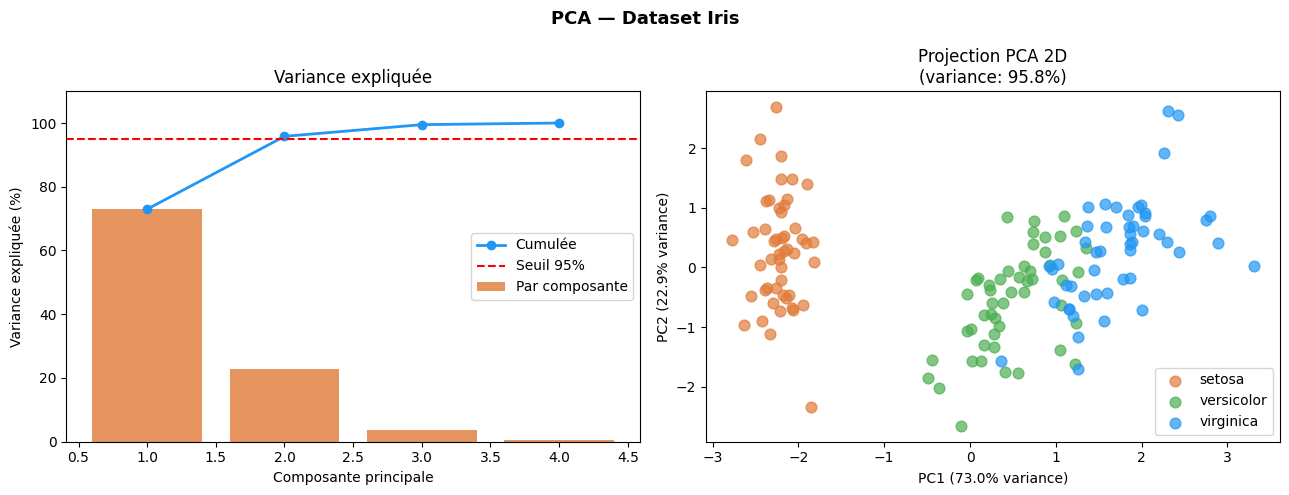


**PC1 + PC2 capturent `95.8%` de la variance totale.**  
On passe de **4 dimensions** à **2 dimensions** avec très peu de perte d'information.


In [8]:
# ── PCA sur le dataset Iris ────────────────────────────────────────────────

# Standardisation obligatoire avant PCA
# (PCA est sensible à l'échelle des données)
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X_iris)

# PCA : garder toutes les composantes pour voir la variance expliquée
pca_full = PCA(n_components=None, random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

# Variance expliquée
var_exp   = pca_full.explained_variance_ratio_
var_cumul = np.cumsum(var_exp)

print("=== Variance expliquée par composante ===")
for i, (v, c) in enumerate(zip(var_exp, var_cumul)):
    barre = '█' * int(v * 40)
    print(f"  PC{i+1} : {v*100:5.1f}%  {barre}  (cumulé : {c*100:.1f}%)")

# PCA en 2D pour visualisation
pca_2d   = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# Visualisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("PCA — Dataset Iris", fontsize=13, fontweight='bold')

# Courbe de variance expliquée
ax1.bar(range(1, len(var_exp)+1), var_exp*100,    color='#e07b39', alpha=0.8, label='Par composante')
ax1.plot(range(1, len(var_cumul)+1), var_cumul*100, color='#2196f3', marker='o', linewidth=2, label='Cumulée')
ax1.axhline(95, color='red', linestyle='--', linewidth=1.5, label='Seuil 95%')
ax1.set_title("Variance expliquée")
ax1.set_xlabel("Composante principale")
ax1.set_ylabel("Variance expliquée (%)")
ax1.set_ylim(0, 110)
ax1.legend()

# Projection 2D
couleurs_iris = ['#e07b39', '#4caf50', '#2196f3']
for i, (nom, couleur) in enumerate(zip(iris.target_names, couleurs_iris)):
    masque = y_iris == i
    ax2.scatter(X_pca_2d[masque, 0], X_pca_2d[masque, 1],
               label=nom, color=couleur, alpha=0.7, s=60)
ax2.set_title(f"Projection PCA 2D\n(variance: {(var_exp[0]+var_exp[1])*100:.1f}%)")
ax2.set_xlabel(f"PC1 ({var_exp[0]*100:.1f}% variance)")
ax2.set_ylabel(f"PC2 ({var_exp[1]*100:.1f}% variance)")
ax2.legend()

plt.tight_layout()
plt.show()

display(Markdown(f"""
**PC1 + PC2 capturent `{(var_exp[0]+var_exp[1])*100:.1f}%` de la variance totale.**  
On passe de **4 dimensions** à **2 dimensions** avec très peu de perte d'information.
"""))

📌 Ce que j'observe

PC1 seule capture ~73% de la variance — la majorité de l'information est dans cette direction.  
Avec PC1 + PC2 on couvre ~96% — on peut réduire de 4 à 2 dimensions sans perdre grand chose.  
Sur le graphique 2D, les 3 espèces d'Iris sont **déjà bien séparées** — la PCA a bien capturé la structure des données.

### 3.3 LDA — Linear Discriminant Analysis

La **LDA** ressemble à la PCA mais avec une différence fondamentale :

| | PCA | LDA |
|-|-----|-----|
| Objectif | Maximiser la **variance** | Maximiser la **séparation entre classes** |
| Supervisée ? | ❌ Non | ✅ Oui (utilise la target) |
| Nombre max de composantes | min(n_features, n_samples) | **n_classes - 1** |
| Usage principal | Compression, visualisation | Classification + réduction |

**Intuition :**
```
PCA cherche les axes où les données sont les plus étalées.
LDA cherche les axes qui séparent le mieux les classes.

Ce n'est pas la même chose !
```

> ⚠️ Avec 3 classes (Iris), LDA produit au maximum **2 composantes** (3-1=2).  
> La LDA est particulièrement efficace quand les classes sont bien définies.

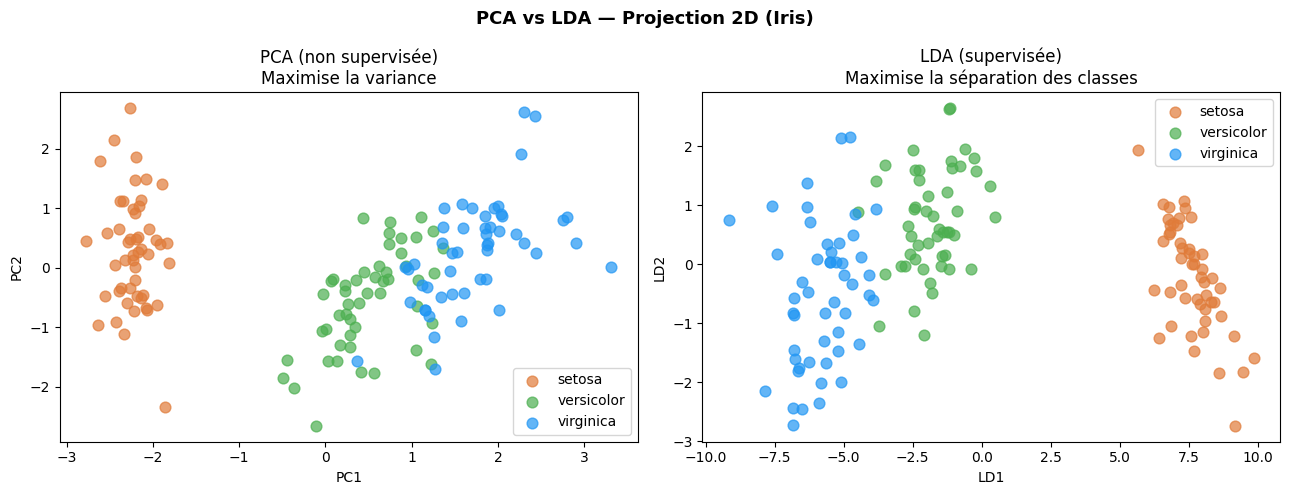

Variance expliquée LDA par composante :
  LD1 : 99.1%
  LD2 : 0.9%


In [9]:
# ── Comparaison PCA vs LDA sur Iris ───────────────────────────────────────

# LDA en 2D (max = n_classes - 1 = 2)
lda = LDA(n_components=2)
X_lda_2d = lda.fit_transform(X_scaled, y_iris)

# Comparaison visuelle PCA vs LDA
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("PCA vs LDA — Projection 2D (Iris)", fontsize=13, fontweight='bold')

for i, (nom, couleur) in enumerate(zip(iris.target_names, couleurs_iris)):
    masque = y_iris == i
    ax1.scatter(X_pca_2d[masque, 0], X_pca_2d[masque, 1],
               label=nom, color=couleur, alpha=0.7, s=60)
    ax2.scatter(X_lda_2d[masque, 0], X_lda_2d[masque, 1],
               label=nom, color=couleur, alpha=0.7, s=60)

ax1.set_title("PCA (non supervisée)\nMaximise la variance")
ax1.set_xlabel("PC1"); ax1.set_ylabel("PC2")
ax1.legend()

ax2.set_title("LDA (supervisée)\nMaximise la séparation des classes")
ax2.set_xlabel("LD1"); ax2.set_ylabel("LD2")
ax2.legend()

plt.tight_layout()
plt.show()

print("Variance expliquée LDA par composante :")
for i, v in enumerate(lda.explained_variance_ratio_):
    print(f"  LD{i+1} : {v*100:.1f}%")

📌 Ce que j'observe

La LDA sépare **beaucoup mieux** les 3 espèces que la PCA sur cet exemple.  
C'est attendu : la LDA optimise **directement** la séparation entre classes.  
La PCA ne "sait" pas qu'il y a des classes — elle compresse juste la variance maximale.

### 3.4 t-SNE — Visualisation de clusters

Le **t-SNE** est conçu pour la **visualisation** — il projette des données haute dimension en 2D ou 3D  
en préservant les **similarités locales** entre les points.

**Différences avec PCA et LDA :**

| | PCA | LDA | t-SNE |
|-|-----|-----|-------|
| Type | Linéaire | Linéaire | **Non-linéaire** |
| Supervisée | Non | Oui | Non |
| Objectif | Variance max | Séparation classes | **Préserver voisinage** |
| Usage | Compression, débruitage | Classification | **Visualisation uniquement** |
| Reproductible ? | ✅ Oui | ✅ Oui | ⚠️ Dépend de `random_state` |

> ⚠️ **Limitations importantes du t-SNE :**
> - Ne pas interpréter les distances entre clusters (non significatives)
> - Ne pas l'utiliser pour la compression (uniquement visualisation)
> - Le paramètre `perplexity` change fortement l'aspect du graphique
> - Lent sur de grands datasets

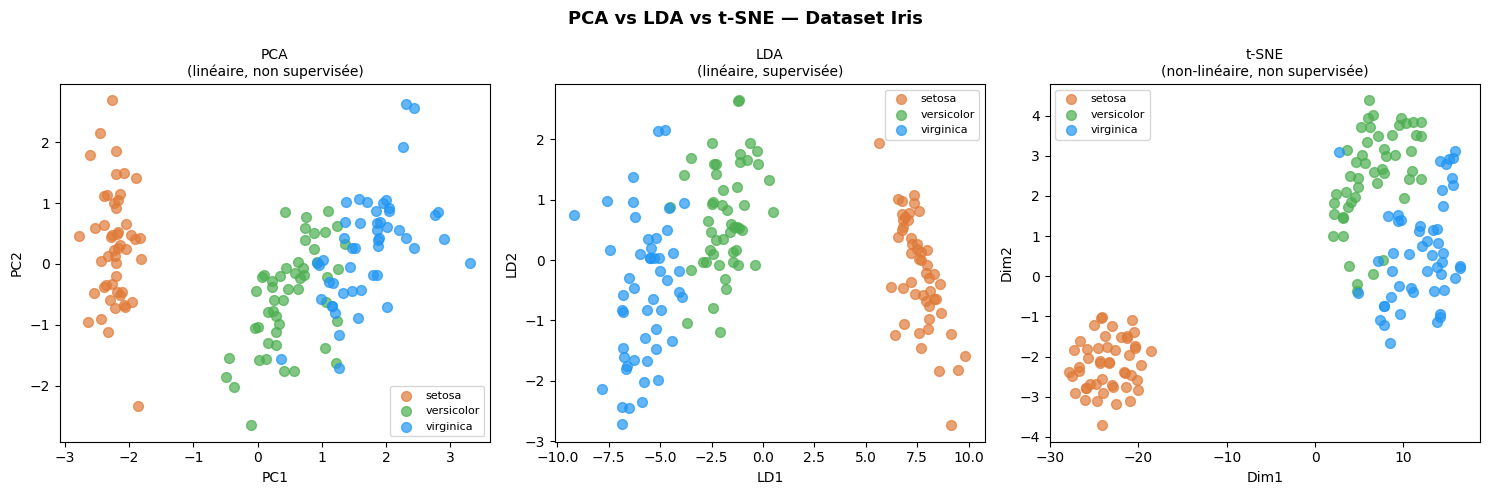

In [10]:
# ── t-SNE sur le dataset Iris ──────────────────────────────────────────────

# t-SNE en 2D
tsne = TSNE(
    n_components = 2,
    perplexity   = 30,    # Nombre de voisins considérés (typique : 5-50)
    random_state = RANDOM_STATE,
    max_iter     = 1000
)
X_tsne = tsne.fit_transform(X_scaled)

# Comparaison des 3 méthodes côte à côte
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("PCA vs LDA vs t-SNE — Dataset Iris", fontsize=13, fontweight='bold')

projections = [
    (X_pca_2d, "PCA\n(linéaire, non supervisée)",  "PC1",  "PC2"),
    (X_lda_2d, "LDA\n(linéaire, supervisée)",       "LD1",  "LD2"),
    (X_tsne,   "t-SNE\n(non-linéaire, non supervisée)", "Dim1", "Dim2"),
]

for ax, (X_proj, titre, xlabel, ylabel) in zip(axes, projections):
    for i, (nom, couleur) in enumerate(zip(iris.target_names, couleurs_iris)):
        masque = y_iris == i
        ax.scatter(X_proj[masque, 0], X_proj[masque, 1],
                  label=nom, color=couleur, alpha=0.7, s=50)
    ax.set_title(titre, fontsize=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

📌 Ce que j'observe

Les 3 méthodes séparent bien les espèces sur Iris, mais de façon différente.  
La LDA donne la meilleure séparation car elle est supervisée.  
Le t-SNE crée des clusters très nets — idéal pour la visualisation exploratoire.  
Mais les distances entre clusters t-SNE ne sont **pas interprétables** comme des distances réelles.

### 3.5 Autres méthodes de réduction

Au-delà de PCA, LDA et t-SNE, d'autres méthodes existent pour des besoins spécifiques :

| Méthode | Principe | Cas d'usage |
|---------|----------|-------------|
| **Autoencodeur** | Réseau neuronal qui compresse puis reconstruit les données | Données complexes, images, texte |
| **ICA** (Independent Component Analysis) | Sépare des sources indépendantes mélangées | Signal audio, EEG, finance |
| **NMF** (Non-negative Matrix Factorization) | Décomposition en facteurs positifs | Texte (topics), images |
| **UMAP** | Comme t-SNE mais plus rapide et paramétrique | Visualisation grands datasets |

```
Autoencodeur — architecture :

Entrée (100D) → [Encodeur] → Code (10D) → [Décodeur] → Reconstruction (100D)
                                ↑
                        Représentation compressée
                        (comme les composantes PCA mais non-linéaire)
```

> 💡 **Règle pratique :**  
> - Données tabulaires → **PCA** ou **LDA**  
> - Visualisation exploratoire → **t-SNE** ou **UMAP**  
> - Données non-structurées complexes (images, texte) → **Autoencodeur**

### 3.6 Combiner Feature Selection et Réduction de dimension

Comme le souligne Florian AUBRY : **les deux approches se complètent**.  
On peut injecter les features les plus importantes **avec** des composantes issues de la réduction.

**Exemple de pipeline combiné :**

```
Dataset (50 features)
        ↓
SelectKBest → 10 meilleures features
        ↓
PCA sur les 10 features → 3 composantes
        ↓
Dataset final : 10 features originales + 3 composantes PCA = 13 colonnes
        ↓
Modèle final (plus riche qu'avec l'une ou l'autre seule)
```

In [11]:
# ── Pipeline combiné : SelectKBest + PCA ──────────────────────────────────

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Pipeline 1 : seulement les features brutes
pipeline_base = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(random_state=RANDOM_STATE, max_iter=500))
])

# Pipeline 2 : SelectKBest avant le modèle
pipeline_kbest = Pipeline([
    ('scaler', StandardScaler()),
    ('select', SelectKBest(score_func=f_classif, k=3)),
    ('clf',    LogisticRegression(random_state=RANDOM_STATE, max_iter=500))
])

# Pipeline 3 : PCA avant le modèle
pipeline_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=2)),
    ('clf',    LogisticRegression(random_state=RANDOM_STATE, max_iter=500))
])

# Entraînement et comparaison
X_tr, X_te, y_tr, y_te = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=RANDOM_STATE, stratify=y_iris
)

resultats_pipeline = {}
for nom, pip in [('Base (4 features)', pipeline_base),
                  ('SelectKBest k=3',   pipeline_kbest),
                  ('PCA 2 composantes', pipeline_pca)]:
    pip.fit(X_tr, y_tr)
    acc = pip.score(X_te, y_te)
    resultats_pipeline[nom] = acc

print("=== Comparaison des pipelines ===")
for nom, acc in resultats_pipeline.items():
    barre = '█' * int(acc * 30)
    print(f"  {nom:25s} : {acc*100:.1f}%  {barre}")

display(Markdown("> 💡 Les performances sont proches sur Iris (dataset simple).  "
                 "Sur des données complexes, la différence peut être plus marquée."))

=== Comparaison des pipelines ===
  Base (4 features)         : 91.1%  ███████████████████████████
  SelectKBest k=3           : 91.1%  ███████████████████████████
  PCA 2 composantes         : 88.9%  ██████████████████████████


> 💡 Les performances sont proches sur Iris (dataset simple).  Sur des données complexes, la différence peut être plus marquée.

📌 Ce que j'observe

Sur Iris (dataset simple), les 3 pipelines donnent des résultats similaires.  
C'est normal : Iris est un dataset propre avec peu de features.  
Sur un dataset réel avec 50+ features et du bruit, la sélection/réduction fait une vraie différence.

---
## 📏 4. Métriques avancées

### 4.1 R² — Coefficient de détermination (régression)

Le **R²** (R-carré) mesure la qualité d'un modèle de **régression**.  
Il répond à la question : *"Quelle proportion de la variance de y mon modèle explique-t-il ?"*

**Formule :**
```
R² = 1 - SSres / SStot

Où :
  SSres = Σ(yᵢ - ŷᵢ)²   → somme des erreurs au carré (résidus)
  SStot = Σ(yᵢ - ȳ)²    → variance totale des données réelles
  ŷᵢ   = valeur prédite par le modèle
  ȳ    = moyenne de toutes les valeurs réelles
```

**Interprétation :**

| Valeur R² | Signification |
|-----------|---------------|
| `R² = 1.0` | Prédictions **parfaites** — toutes les valeurs sont justes |
| `R² = 0.8` | Le modèle explique **80%** de la variance des données |
| `R² = 0.5` | Le modèle explique seulement **50%** |
| `R² = 0.0` | Le modèle ne fait **pas mieux** que prédire la moyenne |
| `R² < 0`   | Le modèle est **pire** que de prédire la moyenne ! |

> 💡 **Analogie :** SSres c'est l'erreur **de ton modèle**.  
> SStot c'est l'erreur d'un modèle stupide qui dirait toujours "la moyenne".  
> R² = à quel point ton modèle est meilleur que ce modèle stupide.

=== R² — Calcul et vérification ===
  Modèle linéaire (sklearn)  : R² = 0.9434
  Modèle linéaire (manuel)   : R² = 0.9434  ← doit être identique
  Modèle 'moyenne' (stupide) : R² = 0.0000  ← toujours = 0

  SSres = 325.96
  SStot = 5757.43
  R² = 1 - 325.96/5757.43 = 0.9434


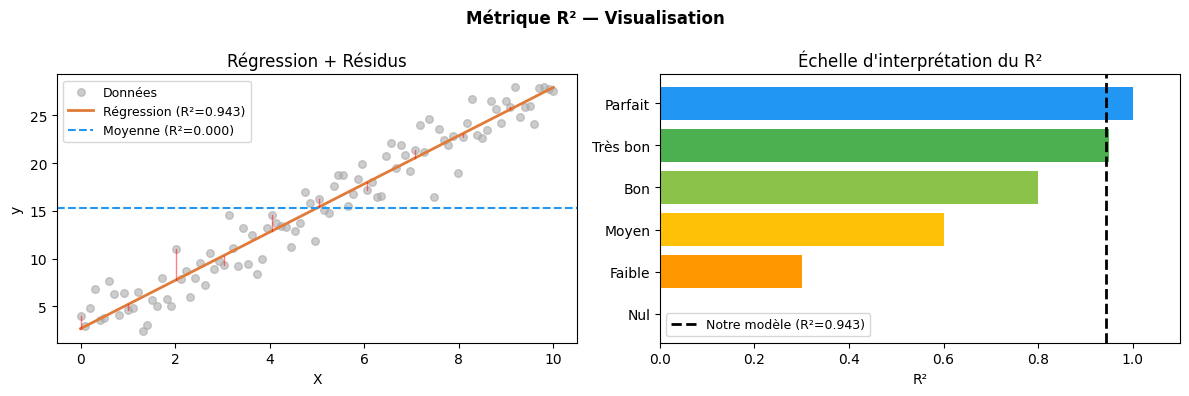

In [12]:
# ── Démonstration R² ───────────────────────────────────────────────────────

# Données de régression synthétiques
np.random.seed(RANDOM_STATE)
X_reg = np.linspace(0, 10, 100).reshape(-1, 1)
y_reg = 2.5 * X_reg.flatten() + 3 + np.random.normal(0, 2, 100)  # Droite + bruit

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Modèle 1 : régression linéaire (bon)
reg_lin = LinearRegression()
reg_lin.fit(X_reg, y_reg)
y_pred_lin = reg_lin.predict(X_reg)
r2_lin = r2_score(y_reg, y_pred_lin)

# Modèle 2 : prédire la moyenne (modèle stupide, R²=0)
y_pred_moy = np.full_like(y_reg, y_reg.mean())
r2_moy = r2_score(y_reg, y_pred_moy)

# Calcul manuel de R² pour comprendre
SSres = np.sum((y_reg - y_pred_lin)**2)
SStot = np.sum((y_reg - y_reg.mean())**2)
r2_manuel = 1 - (SSres / SStot)

print("=== R² — Calcul et vérification ===")
print(f"  Modèle linéaire (sklearn)  : R² = {r2_lin:.4f}")
print(f"  Modèle linéaire (manuel)   : R² = {r2_manuel:.4f}  ← doit être identique")
print(f"  Modèle 'moyenne' (stupide) : R² = {r2_moy:.4f}  ← toujours = 0")
print(f"\n  SSres = {SSres:.2f}")
print(f"  SStot = {SStot:.2f}")
print(f"  R² = 1 - {SSres:.2f}/{SStot:.2f} = {r2_manuel:.4f}")

# Visualisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Métrique R² — Visualisation", fontsize=12, fontweight='bold')

# Données + droite de régression
ax1.scatter(X_reg, y_reg, alpha=0.6, color='#aaaaaa', s=30, label='Données')
ax1.plot(X_reg, y_pred_lin, color='#e07b39', linewidth=2, label=f'Régression (R²={r2_lin:.3f})')
ax1.axhline(y_reg.mean(), color='#2196f3', linestyle='--', linewidth=1.5, label=f'Moyenne (R²={r2_moy:.3f})')
# Résidus (quelques exemples)
for i in range(0, 100, 10):
    ax1.plot([X_reg[i,0], X_reg[i,0]], [y_reg[i], y_pred_lin[i]], color='red', alpha=0.5, linewidth=1)
ax1.set_title("Régression + Résidus")
ax1.set_xlabel("X"); ax1.set_ylabel("y")
ax1.legend(fontsize=9)

# Interprétation visuelle du R²
r2_valeurs = [0.0, 0.3, 0.6, 0.8, 0.95, 1.0]
descriptions = ['Nul', 'Faible', 'Moyen', 'Bon', 'Très bon', 'Parfait']
couleurs_r2  = ['#f44336', '#ff9800', '#ffc107', '#8bc34a', '#4caf50', '#2196f3']
ax2.barh(descriptions, r2_valeurs, color=couleurs_r2)
ax2.axvline(r2_lin, color='black', linestyle='--', linewidth=2, label=f'Notre modèle (R²={r2_lin:.3f})')
ax2.set_title("Échelle d'interprétation du R²")
ax2.set_xlabel("R²")
ax2.set_xlim(0, 1.1)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

📌 Ce que j'observe

La droite de régression passe au milieu des points — les résidus (traits rouges) sont les erreurs du modèle.  
Un R² proche de 0.9 signifie que le modèle explique 90% de la variance — très bon résultat.  
La ligne en pointillés bleue ("prédire la moyenne") aurait un R²=0 — notre modèle est bien meilleur.

### 4.2 ROC — Receiver Operating Characteristic

La courbe **ROC** est une métrique pour les modèles de **classification binaire**.  
Elle répond à : *"Comment évolue le ratio VP/FP quand on change le seuil de décision ?"*

**Rappel — les 4 cas possibles :**
```
                   PRÉDIT
               Positif  Négatif
RÉEL Positif │   VP   │   FN  │
     Négatif │   FP   │   VN  │
```

**Les deux taux de la courbe ROC :**

| Axe | Formule | Signification |
|-----|---------|---------------|
| **Taux VP** (axe Y) | VP / (VP + FN) | Sensibilité : proportion de vrais positifs correctement détectés |
| **Taux FP** (axe X) | FP / (FP + VN) | 1-Spécificité : proportion de faux positifs |

**Construction de la courbe :**
- Pour **chaque seuil de décision** (de 0.0 à 1.0), on calcule le taux VP et le taux FP
- On trace le point correspondant
- La courbe relie tous ces points

```
Taux VP ↑
  1.0 ┤          ╭──────────────
      │      ╭───╯  Bon modèle
  0.5 ┤  ╭───╯
      │╭──╯
  0.0 ┼────────────────────────▶ Taux FP
     0.0      0.5      1.0
      
  La diagonale = modèle aléatoire (inutile)
  Plus la courbe est en haut à gauche = meilleur modèle
```

### 4.3 AUC — Area Under the Curve

L'**AUC** (Area Under the Curve) est la **surface sous la courbe ROC**.  
Elle résume la performance en un seul chiffre entre 0 et 1.

**Interprétation :**

| AUC | Signification |
|-----|---------------|
| `AUC = 1.0` | Classification **parfaite** |
| `AUC = 0.9` | **Excellent** modèle |
| `AUC = 0.8` | **Bon** modèle |
| `AUC = 0.7` | **Acceptable** |
| `AUC = 0.5` | **Aléatoire** — incapacité à classifier |
| `AUC < 0.5` | Pire qu'aléatoire (mais invertissez les labels !) |

**Avantage de l'AUC vs Accuracy :**
- L'AUC est **robuste au déséquilibre des classes**
- Elle mesure la capacité de **discrimination** du modèle, indépendamment du seuil choisi
- Sur un dataset déséquilibré (95% positif), l'accuracy peut être 95% même en prédisant toujours positif — l'AUC serait 0.5 !

=== Résultats ROC / AUC ===
  Régression Logistique          : AUC = 0.8916
  Random Forest                  : AUC = 0.9528
  Aléatoire (baseline)           : AUC = 0.4742


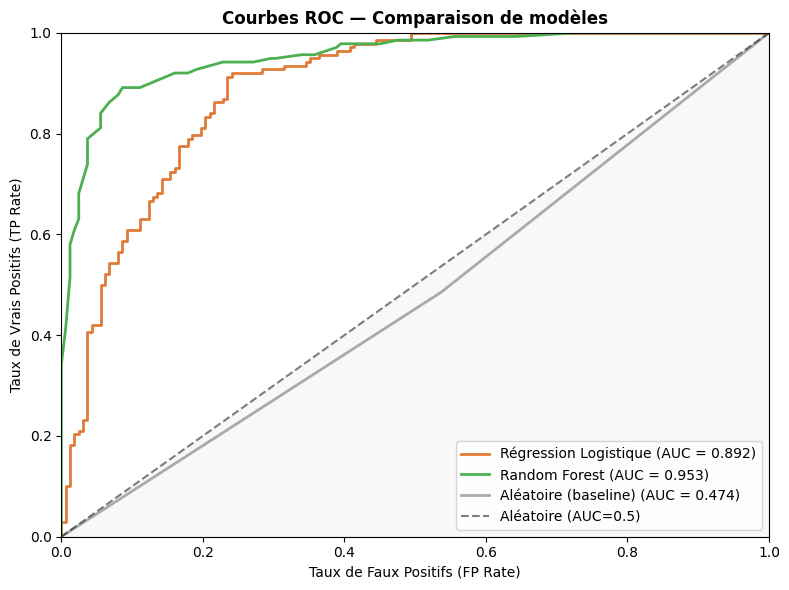

In [13]:
# ── Démonstration ROC & AUC ────────────────────────────────────────────────

# Dataset binaire synthétique
X_roc, y_roc = make_classification(
    n_samples    = 1000,
    n_features   = 10,
    n_informative = 6,
    random_state  = RANDOM_STATE
)
X_tr_roc, X_te_roc, y_tr_roc, y_te_roc = train_test_split(
    X_roc, y_roc, test_size=0.3, random_state=RANDOM_STATE
)

# 3 modèles de qualités différentes
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

modeles_roc = {
    'Régression Logistique': LogisticRegression(random_state=RANDOM_STATE, max_iter=500),
    'Random Forest'        : RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE),
    'Aléatoire (baseline)' : DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
}

fig, ax = plt.subplots(figsize=(8, 6))
couleurs_roc = ['#e07b39', '#4caf50', '#aaaaaa']

print("=== Résultats ROC / AUC ===")
for (nom, clf), couleur in zip(modeles_roc.items(), couleurs_roc):
    clf.fit(X_tr_roc, y_tr_roc)
    y_proba_roc = clf.predict_proba(X_te_roc)[:, 1]  # Probabilité classe 1
    
    fpr, tpr, seuils = roc_curve(y_te_roc, y_proba_roc)
    auc_score = roc_auc_score(y_te_roc, y_proba_roc)
    
    ax.plot(fpr, tpr, color=couleur, linewidth=2, label=f'{nom} (AUC = {auc_score:.3f})')
    print(f"  {nom:30s} : AUC = {auc_score:.4f}")

# Diagonale (modèle aléatoire)
ax.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='Aléatoire (AUC=0.5)')

ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')  # Zone sous la diagonale
ax.set_title("Courbes ROC — Comparaison de modèles", fontsize=12, fontweight='bold')
ax.set_xlabel("Taux de Faux Positifs (FP Rate)")
ax.set_ylabel("Taux de Vrais Positifs (TP Rate)")
ax.legend(fontsize=10)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

📌 Ce que j'observe

Plus la courbe est proche du **coin supérieur gauche**, meilleur est le modèle.  
La diagonale représente un modèle aléatoire (AUC = 0.5) — c'est le seuil plancher.  
Random Forest obtient un AUC plus élevé que la régression logistique sur ce dataset.  
L'AUC est un chiffre simple qui résume toute la courbe ROC en une seule valeur.

### 4.4 Utiliser l'AUC dans TensorFlow/Keras

L'AUC peut être utilisée comme métrique **directement pendant l'entraînement** d'un réseau neuronal.  
Keras la calcule à chaque époque sur le batch de validation.

**Syntaxe :**

```python
import tensorflow as tf
import keras

rnn_model.compile(
    optimizer = tf.keras.optimizers.Adam(1e-3),
    loss      = keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics   = [tf.metrics.AUC()]   # ← AUC comme métrique de suivi
)
```

**Quand utiliser l'AUC vs Accuracy dans Keras ?**

| Situation | Métrique recommandée |
|-----------|--------------------|
| Dataset **équilibré** | Accuracy suffit |
| Dataset **déséquilibré** | **AUC obligatoire** — l'accuracy serait trompeuse |
| Comparaison de modèles | AUC (indépendante du seuil) |
| Classification médicale | AUC (coût des FP et FN différent) |

```python
# Exemple : surveiller AUC + Accuracy + Loss pendant l'entraînement
model.compile(
    optimizer = 'adam',
    loss      = 'binary_crossentropy',
    metrics   = [
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)
```

In [14]:
# ── Récapitulatif des métriques selon le type de problème ─────────────────

display(Markdown("""
### Tableau de décision — Quelle métrique choisir ?

| Type de problème | Classes équilibrées | Classes déséquilibrées |
|-----------------|--------------------|-----------------------|
| **Régression** | R², MSE, RMSE | R², MAE |
| **Classification binaire** | Accuracy, F1 | **AUC, F1-score, Precision/Recall** |
| **Classification multi-classes** | Accuracy, Macro-F1 | Weighted-F1, AUC multiclass |

**Métriques à toujours calculer ensemble :**
- Accuracy + Precision + Recall + F1 + **AUC**
- Matrice de confusion pour voir les erreurs en détail
"""))


### Tableau de décision — Quelle métrique choisir ?

| Type de problème | Classes équilibrées | Classes déséquilibrées |
|-----------------|--------------------|-----------------------|
| **Régression** | R², MSE, RMSE | R², MAE |
| **Classification binaire** | Accuracy, F1 | **AUC, F1-score, Precision/Recall** |
| **Classification multi-classes** | Accuracy, Macro-F1 | Weighted-F1, AUC multiclass |

**Métriques à toujours calculer ensemble :**
- Accuracy + Precision + Recall + F1 + **AUC**
- Matrice de confusion pour voir les erreurs en détail


---
## ✅ 5. Conclusion

Dans cette partie 4, nous avons couvert l'ensemble du programme de Florian AUBRY :

**🔍 Feature Selection (Analyse de composantes)**
- 3 familles : Filtres (statistique), Wrappers (modèle), ML intrinsèque (native)
- Filtres : choisir selon le type de données (Pearson, Spearman, ANOVA, Kendall, Chi², Mutual Info)
- `SelectKBest` : outil sklearn pour les filtres
- `RFE` : wrapper récursif, bon compromis précision/vitesse
- `feature_importances_` : natif dans RandomForest, XGBoost

**📉 Réduction de dimensions**
- **PCA** : composantes linéaires non corrélées, non supervisée
- **LDA** : maximise la séparation des classes, supervisée
- **t-SNE** : non-linéaire, pour la visualisation uniquement
- Les deux approches (sélection + réduction) se **combinent** efficacement

**📏 Métriques avancées**
- **R²** : qualité d'un modèle de régression (0 = mauvais, 1 = parfait)
- **ROC** : courbe VP/FP pour tous les seuils possibles
- **AUC** : surface sous la ROC, robuste au déséquilibre des classes
- Intégration de l'AUC dans TensorFlow/Keras avec `tf.metrics.AUC()`

---

